IMPORTS AND SETUP

In [11]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
sns.set_theme(style="whitegrid", palette="muted")

print("Extracting physical geometry from Chen2020...")
param_virtual = pybamm.ParameterValues("Chen2020") 
# Convert meters to micrometers
L_n = param_virtual["Negative electrode thickness [m]"] * 1e6
L_s = param_virtual["Separator thickness [m]"] * 1e6
L_p = param_virtual["Positive electrode thickness [m]"] * 1e6
L_total = L_n + L_s + L_p

sep_start = L_n
cat_start = L_n + L_s

print(f"Geometry: Anode={L_n:.1f}um, Separator={L_s:.1f}um, Cathode={L_p:.1f}um. Total={L_total:.1f}um")


data_na = np.load('dataset_sodium.npz')
X_na, Y_na, T_na = data_na['X'], data_na['Y'], data_na['T']
data_li = np.load('dataset_lithium.npz')
X_li, Y_li, T_li = data_li['X'], data_li['Y'], data_li['T']

N_samples = X_na.shape[0]

# Convert times to hours
T_na_hours = T_na / 3600.0
T_li_hours = T_li / 3600.0

Extracting physical geometry from Chen2020...
Geometry: Anode=85.2um, Separator=12.0um, Cathode=75.6um. Total=172.8um


PARAMETER SPACE COMPARISON (KDE PLOTS)

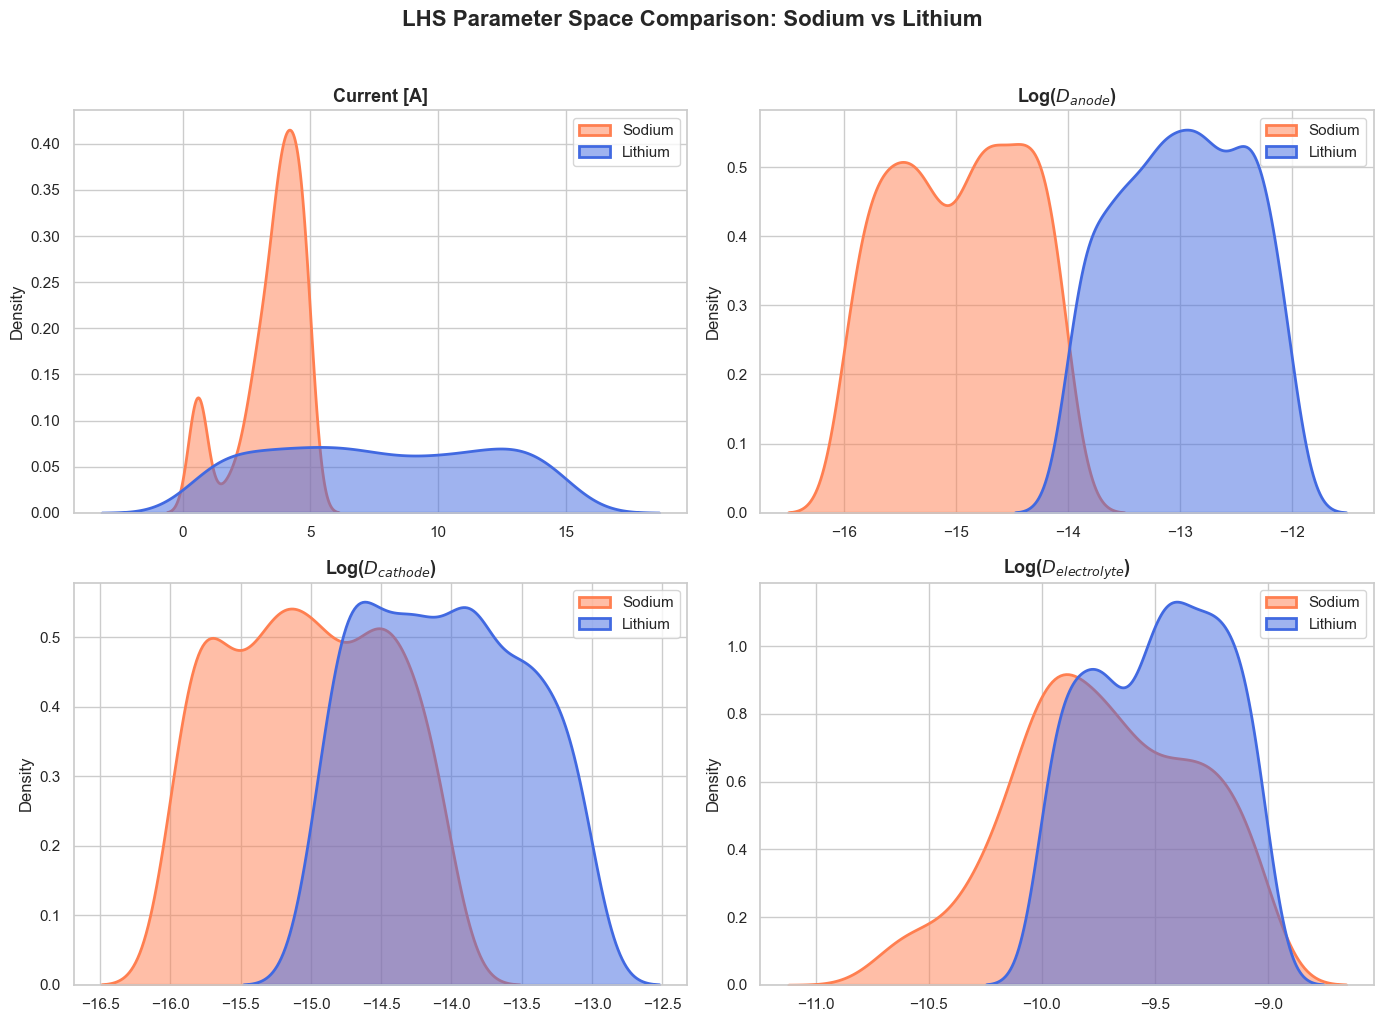

In [14]:
# Instead of two massive pairplots, we do a clean 2x2 grid comparing the distributions 
# to prove that different physical ranges were used.
fig_params, axes = plt.subplots(2, 2, figsize=(14, 10))
fig_params.suptitle('LHS Parameter Space Comparison: Sodium vs Lithium', fontsize=16, fontweight='bold', y=1.02)

param_names = ['Current [A]', 'Log($D_{anode}$)', 'Log($D_{cathode}$)', 'Log($D_{electrolyte}$)']

for i in range(4):
    ax = axes[i//2, i%2]
    
    # Apply log10 to diffusivities (indices 1, 2, 3)
    val_na = X_na[:, i] if i == 0 else np.log10(X_na[:, i])
    val_li = X_li[:, i] if i == 0 else np.log10(X_li[:, i])
    
    sns.kdeplot(val_na, ax=ax, fill=True, color='coral', label='Sodium', alpha=0.5, linewidth=2)
    sns.kdeplot(val_li, ax=ax, fill=True, color='royalblue', label='Lithium', alpha=0.5, linewidth=2)
    
    ax.set_title(param_names[i], fontsize=13, fontweight='bold')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

DISCHARGE TIMES

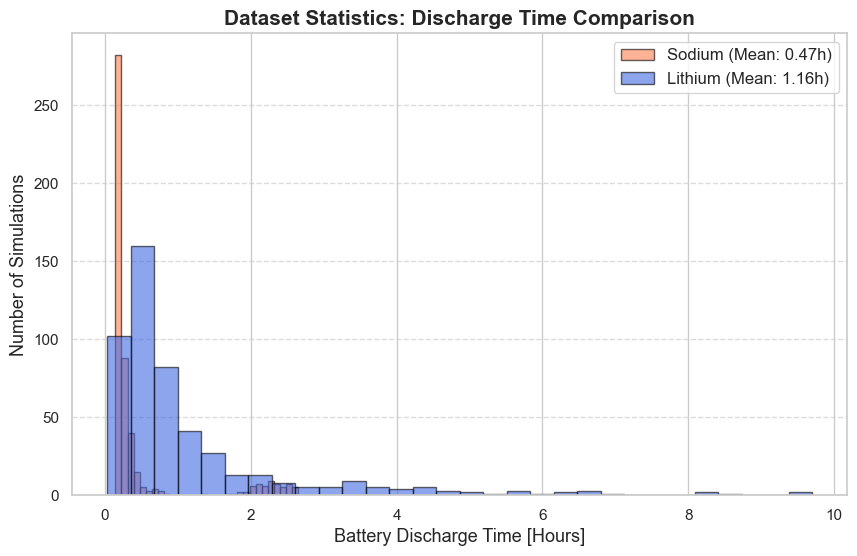

In [15]:
fig_hist, ax_hist = plt.subplots(figsize=(10, 6))

ax_hist.hist(T_na_hours, bins=30, color='coral', edgecolor='black', alpha=0.6, label=f'Sodium (Mean: {np.mean(T_na_hours):.2f}h)')
ax_hist.hist(T_li_hours, bins=30, color='royalblue', edgecolor='black', alpha=0.6, label=f'Lithium (Mean: {np.mean(T_li_hours):.2f}h)')

ax_hist.set_title('Dataset Statistics: Discharge Time Comparison', fontsize=15, fontweight='bold')
ax_hist.set_xlabel('Battery Discharge Time [Hours]', fontsize=13)
ax_hist.set_ylabel('Number of Simulations', fontsize=13)
ax_hist.legend(fontsize=12)
ax_hist.grid(True, axis='y', ls="--", alpha=0.7)

plt.show()

GLOBAL AVERAGES (Na vs Li)

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
C:\Users\angel\AppData\Local\Temp\ipykernel_15536\317554075.py:11: SyntaxWarning: invalid escape sequence '\m'
  axes_comp[0].set_ylabel('Physical Depth [$\mu m$]', fontsize=12, fontweight='bold')


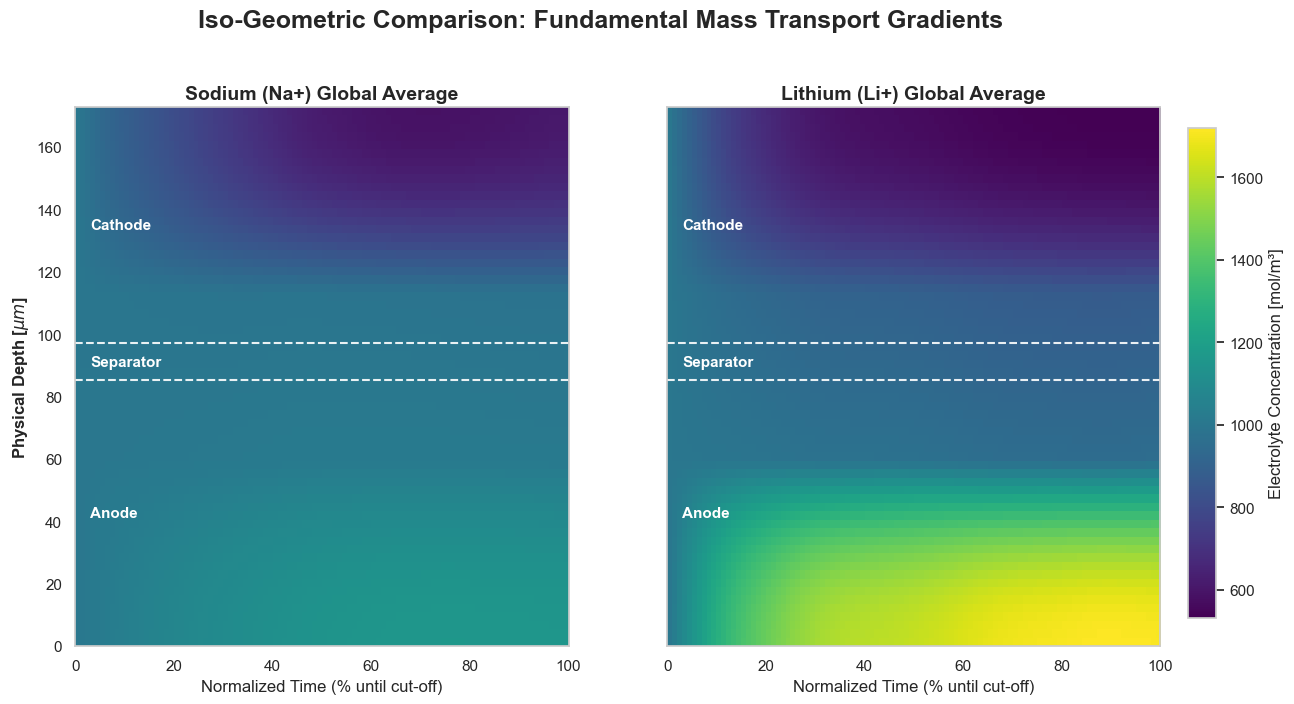

In [ ]:
fig_comp, axes_comp = plt.subplots(1, 2, figsize=(14, 7))

# Calculate a universal vmin and vmax so colors mean the EXACT SAME thing in both plots
universal_vmin = min(np.min(Y_na.mean(axis=0)), np.min(Y_li.mean(axis=0)))
universal_vmax = max(np.max(Y_na.mean(axis=0)), np.max(Y_li.mean(axis=0)))

# Sodium Average
im1 = axes_comp[0].imshow(Y_na.mean(axis=0), aspect='auto', origin='lower', cmap='viridis',
                          extent=[0, 100, 0, L_total], vmin=universal_vmin, vmax=universal_vmax)
axes_comp[0].set_title('Sodium (Na+) Global Average', fontsize=14, fontweight='bold')
axes_comp[0].set_ylabel('Physical Depth [$\mu m$]', fontsize=12, fontweight='bold')

# Lithium Average
im2 = axes_comp[1].imshow(Y_li.mean(axis=0), aspect='auto', origin='lower', cmap='viridis',
                          extent=[0, 100, 0, L_total], vmin=universal_vmin, vmax=universal_vmax)
axes_comp[1].set_title('Lithium (Li+) Global Average', fontsize=14, fontweight='bold')

for ax in axes_comp:
    ax.axhline(y=sep_start, color='white', linestyle='--', linewidth=1.5, alpha=0.9)
    ax.axhline(y=cat_start, color='white', linestyle='--', linewidth=1.5, alpha=0.9)
    ax.text(3, L_n/2, 'Anode', color='white', va='center', fontweight='bold', fontsize=11)
    ax.text(3, L_n + L_s/2, 'Separator', color='white', va='center', fontweight='bold', fontsize=11)
    ax.text(3, L_n + L_s + L_p/2, 'Cathode', color='white', va='center', fontweight='bold', fontsize=11)
    ax.grid(False)
    ax.set_xlabel('Normalized Time (% until cut-off)', fontsize=12)

axes_comp[1].set_yticklabels([])

# Shared Colorbar
fig_comp.subplots_adjust(right=0.9)
cbar_ax_comp = fig_comp.add_axes([0.92, 0.15, 0.02, 0.7])
cbar_comp = fig_comp.colorbar(im1, cax=cbar_ax_comp)
cbar_comp.set_label('Electrolyte Concentration [mol/m³]', fontsize=12)

fig_comp.suptitle('Iso-Geometric Comparison: Fundamental Mass Transport Gradients', fontsize=18, fontweight='bold', y=1.02)
plt.show()